## LOAD DATA & FEATURE ENGINEERING

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../Data/data_withAI.csv')

df['is_jawa'] = (df['bahasa'] == 'jawa').astype(int)
df['is_sunda'] = (df['bahasa'] == 'sunda').astype(int)
df['is_qwen2'] = (df['model'] == 'qwen2').astype(int)
df['is_gemma2'] = (df['model'] == 'gemma2').astype(int)

Y = df['token_output'].values

X_features = df[['panjang_kata_input', 'is_jawa', 'is_sunda', 'is_qwen2', 'is_gemma2']].values

ones = np.ones((len(Y), 1))

X = np.hstack((ones, X_features))

 MLR hanya dapat memproses angka, oleh karena itu kita mengubah variabel kategorikal `bahasa` dan `model` menjadi *Dummy Variables* menggunakan metode *One-Hot Encoding*:

* **Variabel Dependen ($Y$):** `token_output` (Kita ingin memprediksi berapa banyak token yang dihasilkan).
* **Variabel Independen ($X$):**
  * Variabel Kontinu: `panjang_kata_input`.
  * Variabel Dummy Bahasa: `is_jawa` dan `is_sunda`. (Bahasa **Inggris** dijadikan sebagai baseline atau kategori referensi).
  * Variabel Dummy Model: `is_qwen2` dan `is_gemma2`. (Model **Llama3** dijadikan sebagai baseline atau kategori referensi).

Kategori baseline sengaja tidak dibuatkan kolomnya untuk menghindari multikolinearitas sempurna (*dummy variable trap*). Nantinya, interpretasi nilai koefisien pada dummy variabel adalah perbandingannya terhadap baseline ini.

### Pembentukan Matriks Persamaan MLR
Untuk menghitung regresi secara matematis (seperti menggunakan *Ordinary Least Squares* atau OLS), kita membutuhkan bentuk persamaan linier dasar:

$$Y = \beta_0 + \beta_1 X_{panjang\_kata} + \beta_2 X_{jawa} + \beta_3 X_{sunda} + \beta_4 X_{qwen2} + \beta_5 X_{gemma2} + \epsilon$$

Di mana $\beta_0$ adalah intercept. Agar perhitungan matriks $X$ dan koefisien $\beta$ dapat dilakukan secara elegan menggunakan *dot product*, kita harus menambahkan satu kolom berisi angka 1 (vektor *ones*) pada matriks fitur $X$. Kolom angka 1 ini secara otomatis akan menjadi pengali untuk mengestimasi nilai konstanta $\beta_0$.

## KALKULASI NORMAL EQUATION

Beta = (X^T * X)^-1 * X^T * Y

### Estimasi Koefisien OLS Menggunakan Normal Equation (Aljabar Linier)
Untuk mencari nilai koefisien regresi ($\beta$) yang menghasilkan error atau *Residual Sum of Squares* (RSS) paling minimum, kita menggunakan metode **Ordinary Least Squares (OLS)**. 
komputasi ini dilakukan menggunakan **Normal Equation** dengan rumus matriks berikut:

$$\hat{\beta} = (X^T X)^{-1} X^T Y$$

Di mana:
* $X$ adalah matriks fitur (termasuk kolom *intercept*).
* $Y$ adalah vektor target (`token_output`).
* $\hat{\beta}$ adalah vektor koefisien regresi yang ingin dicari (berisi $\beta_0, \beta_1, ... \beta_5$).


In [3]:
#Transpose matriks X
X_T = X.T

# Perkalian titik (dot product) antara X_T dan X
X_T_X = np.dot(X_T, X)

# Inverse dari matriks (X_T_X)
X_T_X_inv = np.linalg.inv(X_T_X)

# Perkalian titik antara X_T dan Y
X_T_Y = np.dot(X_T, Y)

# Hasil akhir koefisien Beta
beta = np.dot(X_T_X_inv, X_T_Y)


**Langkah-langkah Komputasi NumPy:**
1. **`X_T`**: Menghitung transpos dari matriks fitur ($X^T$).
2. **`X_T_X`**: Menghitung *dot product* antara matriks transpos dengan matriks aslinya ($X^T X$).
3. **`X_T_X_inv`**: Mencari nilai invers dari matriks hasil perkalian tersebut ($(X^T X)^{-1}$).
4. **`X_T_Y`**: Menghitung *dot product* antara matriks transpos dengan vektor target ($X^T Y$).
5. **`beta`**: Mengalikan matriks invers dengan hasil $X^T Y$ untuk mendapatkan nilai koefisien akhir ($\hat{\beta}$).

In [4]:
# Hitung prediksi Y (Y_hat = X * Beta)
Y_pred = np.dot(X, beta)

# Sum of Squares Residual (Error)
SS_res = np.sum((Y - Y_pred) ** 2)

# Sum of Squares Total (Varian total dari Y)
SS_tot = np.sum((Y - np.mean(Y)) ** 2)

# Nilai R-Squared
R_squared = 1 - (SS_res / SS_tot)

#TAMPILKAN HASIL
print(f"Intercept (Beta_0)         : {beta[0]:.4f}")
print(f"Koefisien panjang_input    : {beta[1]:.4f}")
print(f"Koefisien is_jawa          : {beta[2]:.4f}")
print(f"Koefisien is_sunda         : {beta[3]:.4f}")
print(f"Koefisien is_qwen2         : {beta[4]:.4f}")
print(f"Koefisien is_gemma2        : {beta[5]:.4f}")
print("-" * 46)
print(f"R-Squared                  : {R_squared:.4f}")

Intercept (Beta_0)         : 52.6990
Koefisien panjang_input    : 0.6208
Koefisien is_jawa          : 9.4656
Koefisien is_sunda         : 12.2865
Koefisien is_qwen2         : 0.0200
Koefisien is_gemma2        : -15.1667
----------------------------------------------
R-Squared                  : 0.2316


### Evaluasi Model (R-Squared) dan Prediksi
Setelah mendapatkan nilai koefisien ($\hat{\beta}$), kita perlu mengukur seberapa baik model persamaan linier ini dapat menjelaskan variansi dari data asli. Metrik yang digunakan adalah **Koefisien Determinasi atau R-Squared ($R^2$)**.

Perhitungan dilakukan dengan langkah matematis berikut:
1. **Membuat Prediksi ($\hat{Y}$):** Menghitung nilai prediksi model menggunakan *dot product* dari matriks $X$ dan vektor koefisien $\beta$.
   $$\hat{Y} = X \cdot \beta$$
2. **Residual Sum of Squares ($SS_{res}$):** Menghitung total variansi error atau selisih kuadrat antara nilai asli dan nilai prediksi.
   $$SS_{res} = \sum (Y - \hat{Y})^2$$
3. **Total Sum of Squares ($SS_{tot}$):** Menghitung total variansi bawaan dari data target (seberapa jauh data tersebar dari rata-ratanya).
   $$SS_{tot} = \sum (Y - \bar{Y})^2$$
4. **Koefisien Determinasi ($R^2$):** Menghitung rasio variansi yang berhasil dijelaskan oleh model. Nilai $R^2$ berkisar antara 0 hingga 1.
   $$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

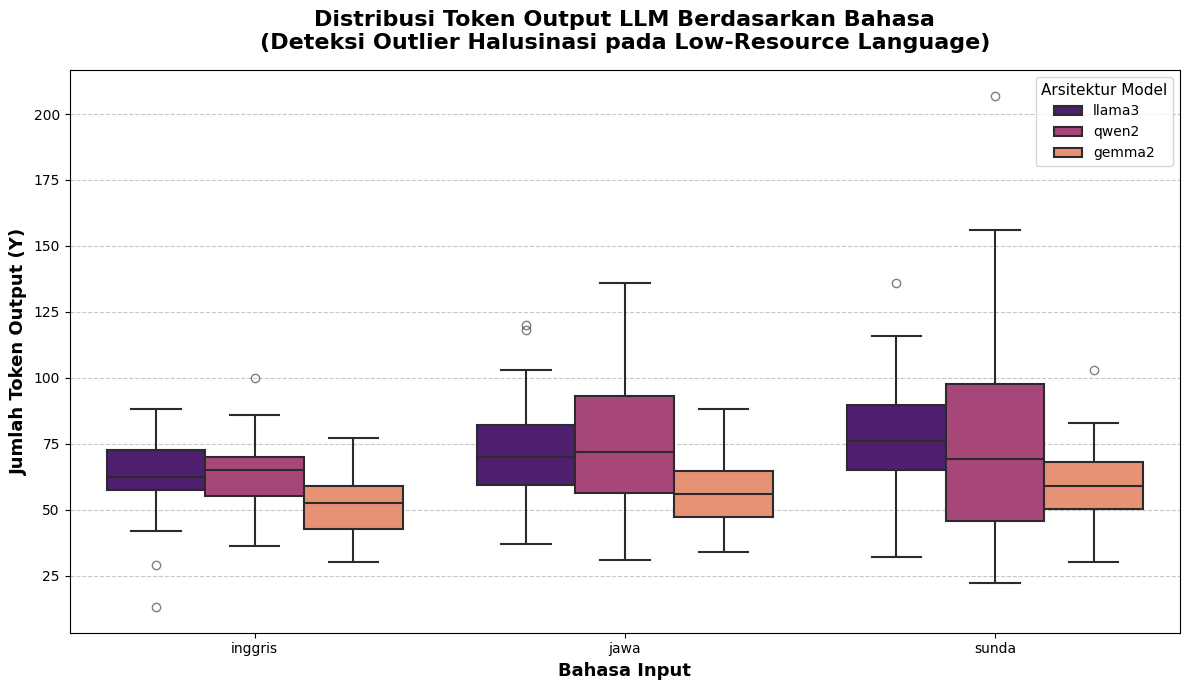

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df, 
    x='bahasa', 
    y='token_output', 
    hue='model', 
    palette='magma',
    linewidth=1.5,
    flierprops=dict(marker='o', color='red', markersize=6, alpha=0.6)
)

plt.title('Distribusi Token Output LLM Berdasarkan Bahasa\n(Deteksi Outlier Halusinasi pada Low-Resource Language)', 
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Bahasa Input', fontsize=13, fontweight='bold')
plt.ylabel('Jumlah Token Output (Y)', fontsize=13, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Arsitektur Model', title_fontsize='11', fontsize='10', loc='upper right')

plt.tight_layout()
plt.show()

<>:14: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:26: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:14: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:26: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
/var/folders/2k/9v42dhzd2rdg1nkfsqt49skw0000gn/T/ipykernel_18295/2517225642.py:14: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  axes[0].set_xlabel('Predicted Token Output ($\hat{Y}$)', fontsize=12)
/var/folders/2k/9v42dhzd2rdg1nkfsqt49skw0000gn/T/ipykernel_18295/2517225642.py:26:

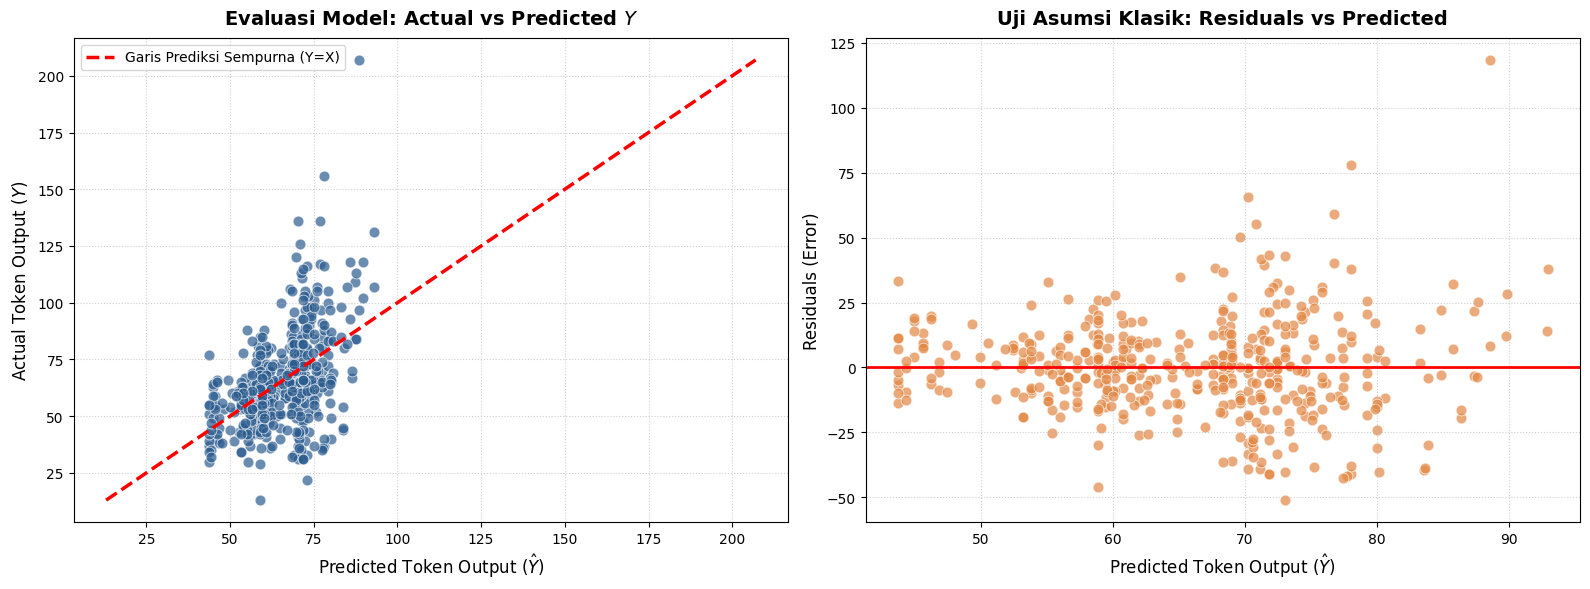

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x=Y_pred, y=Y, ax=axes[0], color='#2b5c8f', alpha=0.7, edgecolor='w', s=60)


min_val = min(min(Y_pred), min(Y))
max_val = max(max(Y_pred), max(Y))
axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2.5, label='Garis Prediksi Sempurna (Y=X)')

axes[0].set_title('Evaluasi Model: Actual vs Predicted $Y$', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Token Output ($\hat{Y}$)', fontsize=12)
axes[0].set_ylabel('Actual Token Output ($Y$)', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.6)

residuals = Y - Y_pred 

sns.scatterplot(x=Y_pred, y=residuals, ax=axes[1], color='#e28743', alpha=0.7, edgecolor='w', s=60)

axes[1].axhline(y=0, color='red', linestyle='-', linewidth=2)

axes[1].set_title('Uji Asumsi Klasik: Residuals vs Predicted', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Predicted Token Output ($\hat{Y}$)', fontsize=12)
axes[1].set_ylabel('Residuals (Error)', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


### Analisis Visual (Actual vs Predicted & Residuals)
Untuk memvalidasi kelayakan model regresi, kita mengevaluasi dua plot diagnostik di atas:

**1. Evaluasi Model: Actual vs Predicted $Y$ (Plot Kiri)**
* Plot ini membandingkan prediksi jumlah token dari model MLR (sumbu X) dengan jumlah token aktual dari eksperimen (sumbu Y). Garis putus-putus merah merepresentasikan prediksi sempurna ($Y = \hat{Y}$).
* **Analisis:** Terlihat mayoritas titik berkumpul di sekitar garis merah pada rentang 40-90 token. Namun, model regresi kita cenderung mengalami *underfitting* saat memprediksi *outlier* atas (seperti teks bahasa Sunda yang pecah hingga >150 token). Regresi linier memprediksi secara konservatif sehingga tidak mampu menjangkau nilai-nilai ekstrem tersebut.

**2. Uji Asumsi Klasik: Residuals vs Predicted (Plot Kanan)**
* Plot ini digunakan untuk menguji asumsi **Homoskedastisitas** (apakah error memiliki variansi yang konstan).
* **Analisis:** Titik-titik sisaan (*residuals*) tersebar di sekitar garis nol, yang berarti secara rata-rata, galat model adalah nol. Akan tetapi, terlihat adanya pola **Heteroskedastisitas**, di mana sebaran *error* semakin melebar (membentuk corong) seiring dengan membesarnya nilai prediksi. Selain itu, terdapat *outliers* positif yang jauh di atas garis (residual > 100).
* **Kesimpulan Diagnostik:** Pelanggaran asumsi homoskedastisitas ini menegaskan kembali bahwa *Multiple Linear Regression* standar memiliki keterbatasan dalam memodelkan *output* AI secara presisi karena adanya *noise* atau variansi ekstrem bawaan dari cara kerja *tokenizer* LLM ketika menemui *Out-of-Vocabulary* (OOV) *words*.

---

### Hasil Regresi (Koefisien & R-Squared)
Berdasarkan *output* perhitungan regresi OLS di Cell [4], didapatkan:

* **Evaluasi Model ($R^2$):** Nilai $R^2$ sebesar **0.2316** menunjukkan bahwa model regresi ini hanya mampu menjelaskan **23.16%** dari variansi jumlah `token_output`. Angka yang relatif rendah ini sangat wajar dan dapat dimaklumi dalam analisis Generative AI. LLM memiliki sifat stokastik (dipengaruhi parameter seperti *temperature* dan *top-p*) yang membuat panjang output bervariasi meskipun *prompt* yang diberikan persis sama. 
* **Intercept ($\beta_0$ = 52.6990):** Jika variabel lain diabaikan (panjang input 0, menggunakan bahasa Inggris, dan model Llama3), estimasi dasar jumlah token yang dihasilkan adalah sekitar 52 hingga 53 token.
* **Pengaruh Panjang Input ($\beta_1$ = 0.6208):** Setiap penambahan 1 kata pada prompt input, model akan membalas dengan tambahan sekitar **0.62 token**.
* **Pengaruh Bahasa (Pembuktian Inefisiensi Tokenisasi):**
  * **Jawa ($\beta_2$ = 9.4656):** Meminta model menjawab dalam bahasa Jawa akan memicu penalti sebesar **~9.47 token** ekstra dibandingkan bahasa Inggris.
  * **Sunda ($\beta_3$ = 12.2865):** Bahasa Sunda memberikan penalti token paling besar, yaitu **~12.29 token** lebih banyak dari bahasa Inggris. Ini membuktikan secara matematis temuan di tahap EDA bahwa perbendaharaan *tokenizer* untuk bahasa daerah sangat tidak efisien.
* **Pengaruh Arsitektur Model:**
  * **Qwen2 ($\beta_4$ = 0.0200):** Jumlah token yang dihasilkan Qwen2 hampir identik dengan Llama3 (selisih hanya 0.02 token, sangat tidak signifikan).
  * **Gemma2 ($\beta_5$ = -15.1667):** Model Gemma2 memiliki gaya bahasa yang jauh lebih ringkas, menghasilkan sekitar **15.17 token lebih sedikit** dibandingkan dengan Llama3.